# `history_comfort` — Threshold Intuitions

**Source:** `navsim/planning/simulation/planner/pdm_planner/scoring/pdm_comfort_metrics.py`

The `history_comfort` metric is **binary** (0 or 1). It passes only if **all six** sub-metrics are within bounds simultaneously, across the **entire** trajectory (past history prepended to agent future).

| # | Sub-metric | Threshold | Unit |
|---|---|---|---|
| 1 | Longitudinal acceleration | (−4.05, +2.40) | m/s² |
| 2 | Lateral acceleration | ±4.89 | m/s² |
| 3 | Magnitude jerk | ±8.37 | m/s³ |
| 4 | Longitudinal jerk | ±4.13 | m/s³ |
| 5 | Yaw acceleration | ±1.93 | rad/s² |
| 6 | Yaw rate | ±0.95 | rad/s |

Each section simulates a minimal trajectory designed to sit **right at** one threshold.  
Each figure shows:
- **Left — BEV:** vehicle boxes at 0.5 s intervals, colored early→late (purple→yellow). Box spacing shows speed; box rotation shows heading change.
- **Right — time series:** the computed metric against the threshold line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import savgol_filter

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

# ── Simulation constants (match navsim defaults) ──────────────────────────────
DT   = 0.1
T    = 5.0
time = np.arange(0, T + DT, DT)
N    = len(time)

# ── Thresholds from pdm_comfort_metrics.py ────────────────────────────────────
MAX_LON_ACCEL =  2.40
MIN_LON_ACCEL = -4.05
MAX_LAT_ACCEL =  4.89
MAX_MAG_JERK  =  8.37
MAX_LON_JERK  =  4.13
MAX_YAW_ACCEL =  1.93
MAX_YAW_RATE  =  0.95

# Pacifica vehicle dimensions (approximate)
VEH_LENGTH = 4.91   # m
VEH_WIDTH  = 2.10   # m

print("Constants loaded.")

Constants loaded.


In [2]:
# ── Kinematics helpers ────────────────────────────────────────────────────────

def euler_integrate(rate_array, init=0.0):
    vals = np.zeros(N)
    vals[0] = init
    for i in range(1, N):
        vals[i] = vals[i - 1] + rate_array[i - 1] * DT
    return vals

def xy_from_speed_heading(speed, heading, x0=0.0, y0=0.0):
    x = np.zeros(N); y = np.zeros(N)
    x[0] = x0; y[0] = y0
    for i in range(1, N):
        x[i] = x[i-1] + speed[i-1] * np.cos(heading[i-1]) * DT
        y[i] = y[i-1] + speed[i-1] * np.sin(heading[i-1]) * DT
    return x, y

def sg_smooth(signal, window=8, poly=2):
    return savgol_filter(signal, window_length=min(window, N), polyorder=poly)

def sg_diff(signal, deriv=1, window=15, poly=2):
    return savgol_filter(signal, window_length=min(window, N),
                         polyorder=poly, deriv=deriv, delta=DT)

def phase_unwrap(headings):
    two_pi = 2.0 * np.pi
    adj = np.zeros_like(headings)
    adj[1:] = np.cumsum(np.round(np.diff(headings) / two_pi))
    return headings - two_pi * adj


# ── BEV drawing ───────────────────────────────────────────────────────────────

def draw_bev(ax, x, y, heading, step=5,
             veh_length=VEH_LENGTH, veh_width=VEH_WIDTH,
             cmap_name="plasma"):
    """
    Bird's-eye view: vehicle boxes at `step`-timestep intervals.
    Color encodes time: purple (t=0) → yellow (t=T).
    Box spacing encodes speed; box rotation encodes heading.
    """
    cmap = plt.get_cmap(cmap_name)
    idxs = np.arange(0, N, step)

    # Thin ghost path
    ax.plot(x, y, color="gray", lw=1, alpha=0.35, ls="--", zorder=1)

    half_l, half_w = veh_length / 2, veh_width / 2
    # corners in vehicle frame: front = +x
    base_corners = np.array([
        [-half_l, -half_w],
        [ half_l, -half_w],
        [ half_l,  half_w],
        [-half_l,  half_w],
    ])

    for rank, idx in enumerate(idxs):
        frac  = rank / max(len(idxs) - 1, 1)
        color = cmap(frac)
        h     = heading[idx]
        cos_h, sin_h = np.cos(h), np.sin(h)
        rot   = np.array([[cos_h, -sin_h], [sin_h, cos_h]])
        world = base_corners @ rot.T + np.array([x[idx], y[idx]])

        poly = mpatches.Polygon(
            world, closed=True,
            fc=color, ec="black", alpha=0.75, lw=0.6, zorder=2
        )
        ax.add_patch(poly)

        # small dot at vehicle front to show heading
        ax.plot(
            x[idx] + half_l * cos_h,
            y[idx] + half_l * sin_h,
            "o", color="black", ms=2, zorder=3
        )

    ax.plot(x[0],  y[0],  "g*", ms=11, zorder=4, label="t = 0 s")
    ax.plot(x[-1], y[-1], "r*", ms=11, zorder=4, label=f"t = {T:.0f} s")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, T))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="time [s]", shrink=0.65, pad=0.02)

    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)


# ── Combined plot helper ──────────────────────────────────────────────────────

def plot_metric(x, y, heading, metric_vals, threshold, metric_name, unit,
                bev_title, metric_title, color_metric="#1565C0",
                mirror=False, extra_lines=None, bev_step=5):
    """
    1×2 figure: left = BEV, right = metric time series.
    extra_lines: list of (values, color, ls, label) for additional curves.
    """
    fig, (ax_bev, ax_ts) = plt.subplots(1, 2, figsize=(13, 5))

    draw_bev(ax_bev, x, y, heading, step=bev_step)
    ax_bev.set_title(bev_title, fontsize=8)

    ax_ts.plot(time, metric_vals, color=color_metric, lw=2, label=metric_name)
    ax_ts.axhline( threshold, color="red",    lw=1.5, ls="--",
                  label=f"+threshold = {threshold} {unit}")
    if mirror:
        ax_ts.axhline(-threshold, color="orange", lw=1.5, ls="--",
                      label=f"\u2212threshold = {-threshold} {unit}")
    if extra_lines:
        for vals, c, ls, lbl in extra_lines:
            ax_ts.plot(time, vals, color=c, lw=2, ls=ls, label=lbl)
    ax_ts.set_xlabel("time [s]")
    ax_ts.set_ylabel(f"{metric_name} [{unit}]")
    ax_ts.set_title(metric_title, fontsize=8)
    ax_ts.legend(fontsize=8)
    ax_ts.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print("Helpers loaded.")

Helpers loaded.


---
## 1. Longitudinal Acceleration (+2.40 m/s²)

**Scenario:** vehicle starts from rest and holds exactly +2.40 m/s² throughout.

After 5 s → speed = **12 m/s = 43 km/h** over **30 m**.

**BEV read:** boxes are closely spaced early (low speed) and spread apart later — you can see the vehicle accelerating. All boxes point right (straight line, no heading change).

> **Real-world feel:** moderate city pull-away — like merging onto a ring road from a standing start. Comfortable and unremarkable. Going any harder would fail this metric.

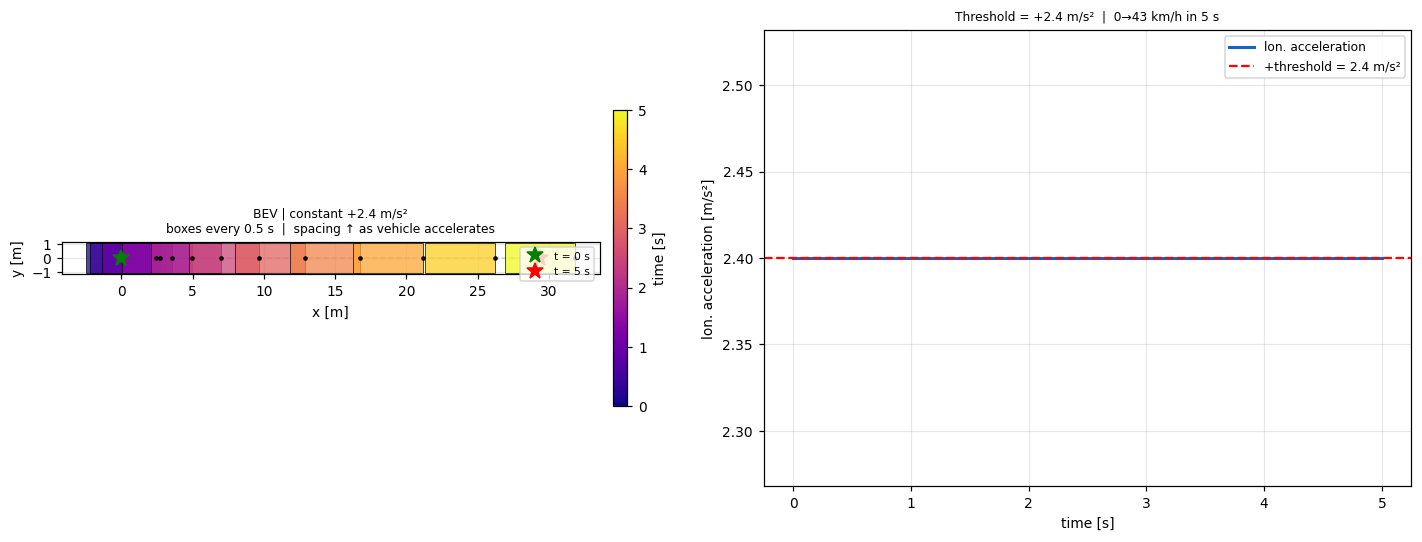

In [3]:
accel_lon    = np.full(N, MAX_LON_ACCEL)
speed_lon    = euler_integrate(accel_lon, init=0.0)
heading_lon  = np.zeros(N)
x, y         = xy_from_speed_heading(speed_lon, heading_lon)
accel_smooth = sg_smooth(accel_lon)

plot_metric(
    x, y, heading_lon, accel_smooth,
    threshold=MAX_LON_ACCEL,
    metric_name="lon. acceleration", unit="m/s\u00b2",
    bev_title=(
        f"BEV | constant +{MAX_LON_ACCEL} m/s\u00b2\n"
        f"boxes every 0.5 s  |  spacing \u2191 as vehicle accelerates"
    ),
    metric_title=f"Threshold = +{MAX_LON_ACCEL} m/s\u00b2  |  0\u219243 km/h in 5 s",
    color_metric="#1565C0",
)

---
## 2. Longitudinal Acceleration — Braking (−4.05 m/s²)

**Scenario:** vehicle enters at 60 km/h and brakes at exactly −4.05 m/s².  
Stops in **4.1 s** over **34 m**.

**BEV read:** boxes are wide-spread early (high speed) and bunch together as the vehicle decelerates to a stop — the opposite pattern from acceleration.

> **Real-world feel:** firm but controlled emergency stop. ABS-level panic braking (~−8 m/s²) would hard-fail this metric.

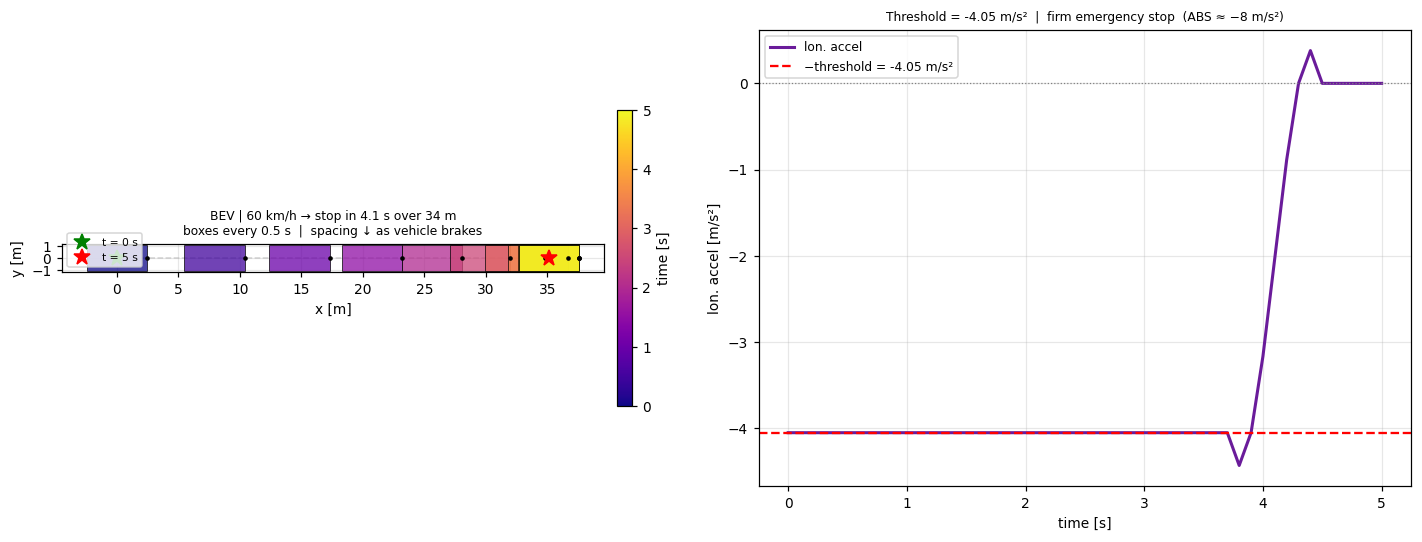

In [4]:
v_init    = 60 / 3.6
stop_t    = v_init / abs(MIN_LON_ACCEL)
accel_brk = np.where(time < stop_t, MIN_LON_ACCEL, 0.0)
speed_brk = np.maximum(euler_integrate(accel_brk, init=v_init), 0.0)
heading_brk = np.zeros(N)
x, y      = xy_from_speed_heading(speed_brk, heading_brk)
accel_s   = sg_smooth(accel_brk)

fig, (ax_bev, ax_ts) = plt.subplots(1, 2, figsize=(13, 5))

draw_bev(ax_bev, x, y, heading_brk)
ax_bev.set_title(
    f"BEV | 60 km/h \u2192 stop in {stop_t:.1f} s over {np.trapz(speed_brk, dx=DT):.0f} m\n"
    "boxes every 0.5 s  |  spacing \u2193 as vehicle brakes",
    fontsize=8
)

ax_ts.plot(time, accel_s, color="#6A1B9A", lw=2, label="lon. accel")
ax_ts.axhline(MIN_LON_ACCEL, color="red",  lw=1.5, ls="--",
              label=f"\u2212threshold = {MIN_LON_ACCEL} m/s\u00b2")
ax_ts.axhline(0, color="gray", lw=0.8, ls=":")
ax_ts.set_xlabel("time [s]")
ax_ts.set_ylabel("lon. accel [m/s\u00b2]")
ax_ts.set_title(
    f"Threshold = {MIN_LON_ACCEL} m/s\u00b2  |  firm emergency stop  (ABS \u2248 \u22128 m/s\u00b2)",
    fontsize=8
)
ax_ts.legend(fontsize=8)
ax_ts.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Lateral Acceleration (±4.89 m/s²)

**Scenario:** constant-speed circular arc at 30 km/h.  
At threshold: `r = v² / a_lat = 8.33² / 4.89 ≈ 14 m` — a very tight corner.  
Over 5 s the vehicle turns through **≈170°** (nearly a full U-turn).

**BEV read:** boxes are evenly spaced (constant speed) and progressively rotated — you can read the tight radius directly from how quickly the vehicle turns.

> **Real-world feel:** aggressively fast exit of a tight city corner or mini-roundabout. At 50 km/h, the same lateral acceleration needs a ~40 m radius — a normal highway on-ramp.

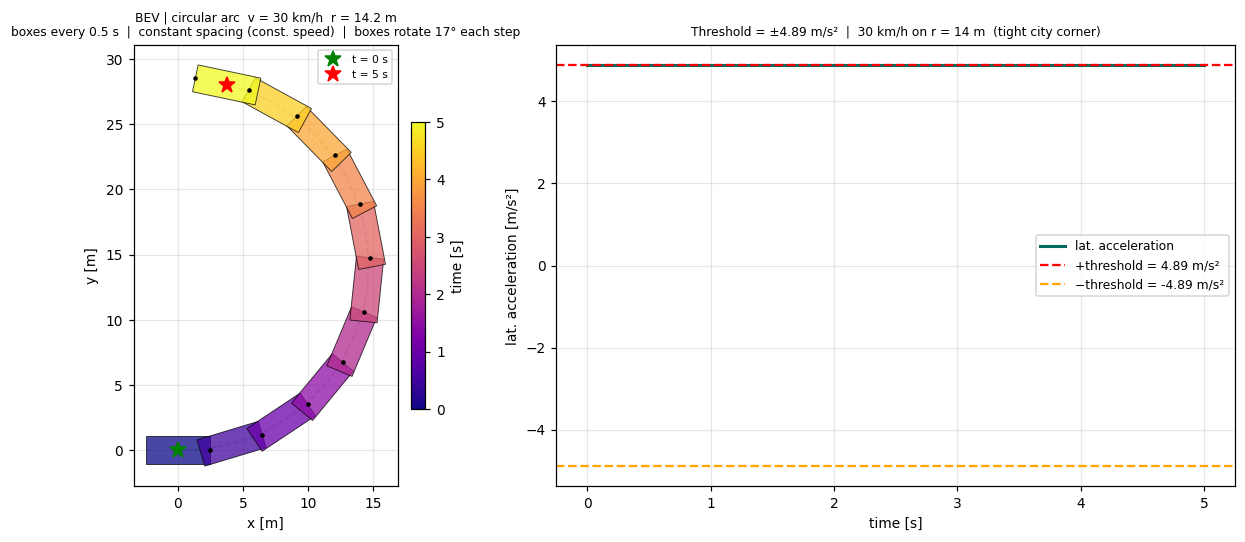

In [5]:
v_lat       = 30 / 3.6
r_lat       = v_lat**2 / MAX_LAT_ACCEL
omega       = v_lat / r_lat
heading_lat = euler_integrate(np.full(N, omega), init=0.0)
x, y        = xy_from_speed_heading(np.full(N, v_lat), heading_lat)

plot_metric(
    x, y, heading_lat,
    np.full(N, MAX_LAT_ACCEL),
    threshold=MAX_LAT_ACCEL,
    metric_name="lat. acceleration", unit="m/s\u00b2",
    bev_title=(
        f"BEV | circular arc  v = {v_lat*3.6:.0f} km/h  r = {r_lat:.1f} m\n"
        f"boxes every 0.5 s  |  constant spacing (const. speed)  |  boxes rotate {np.degrees(omega*DT*5):.0f}\u00b0 each step"
    ),
    metric_title=(
        f"Threshold = \u00b1{MAX_LAT_ACCEL} m/s\u00b2  |  "
        f"30 km/h on r = {r_lat:.0f} m  (tight city corner)"
    ),
    color_metric="#00695C",
    mirror=True,
)

---
## 4. Magnitude Jerk (±8.37 m/s³)

Jerk = rate of change of acceleration magnitude.

**Scenario:** acceleration ramps 0 → +2.40 m/s² in `t_ramp ≈ 290 ms` (~3 timesteps), then holds constant.

**BEV read:** the first two or three boxes are nearly on top of each other (vehicle barely moved from rest), then spacing grows rapidly — you can see the abrupt speed onset that creates the jerk spike.

> **Real-world feel:** briskly flooring the accelerator — full acceleration kicks in within 300 ms. This is the **loosest** jerk limit. Stepping on the gas in ~100 ms would exceed it.

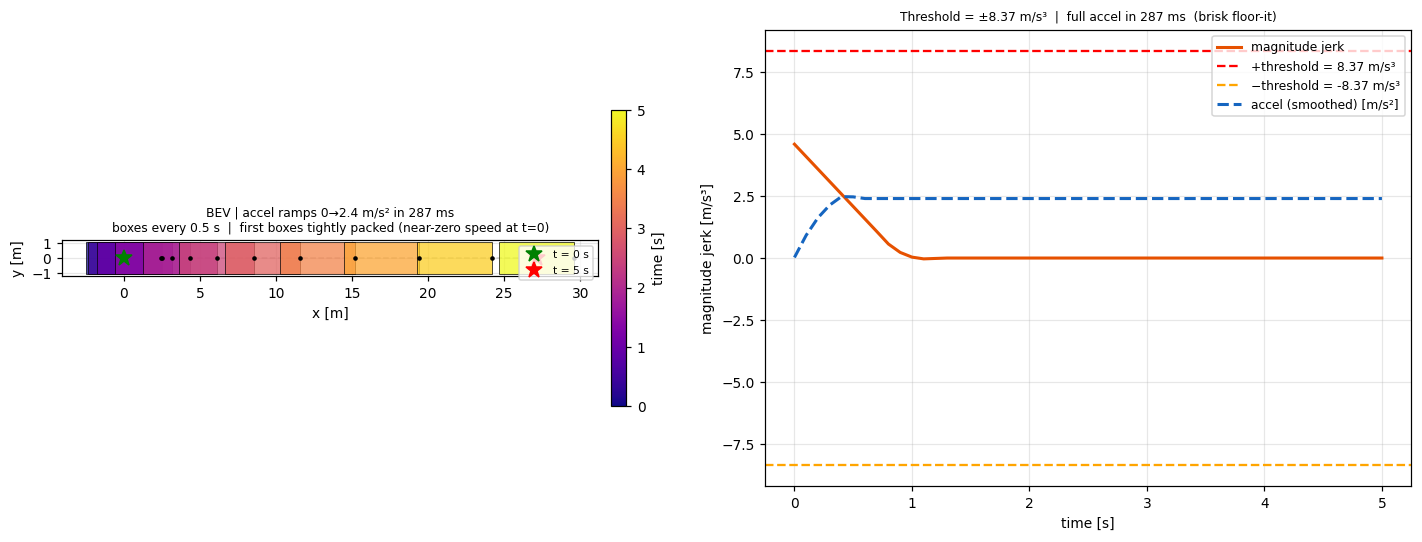

In [6]:
t_ramp3  = MAX_LON_ACCEL / MAX_MAG_JERK
accel3   = np.clip(np.where(time <= t_ramp3,
                             (MAX_LON_ACCEL / t_ramp3) * time,
                             MAX_LON_ACCEL), 0, MAX_LON_ACCEL)
accel3_s = sg_smooth(accel3)
jerk3    = sg_diff(accel3_s, deriv=1, window=15)
speed3   = euler_integrate(accel3, init=0.0)
heading3 = np.zeros(N)
x, y     = xy_from_speed_heading(speed3, heading3)

plot_metric(
    x, y, heading3, jerk3,
    threshold=MAX_MAG_JERK,
    metric_name="magnitude jerk", unit="m/s\u00b3",
    bev_title=(
        f"BEV | accel ramps 0\u2192{MAX_LON_ACCEL} m/s\u00b2 in {t_ramp3*1000:.0f} ms\n"
        "boxes every 0.5 s  |  first boxes tightly packed (near-zero speed at t=0)"
    ),
    metric_title=(
        f"Threshold = \u00b1{MAX_MAG_JERK} m/s\u00b3  |  "
        f"full accel in {t_ramp3*1000:.0f} ms  (brisk floor-it)"
    ),
    color_metric="#E65100",
    mirror=True,
    extra_lines=[(accel3_s, "#1565C0", "--", "accel (smoothed) [m/s\u00b2]")],
)

---
## 5. Longitudinal Jerk (±4.13 m/s³)

Same setup as magnitude jerk but at the tighter longitudinal threshold.

`t_ramp = 2.40 / 4.13 ≈ 580 ms` — **twice as slow** as the magnitude jerk limit.

**BEV read:** the early boxes are still close together but the spacing grows more gradually than in the magnitude jerk scenario — you can see the smoother onset.

> **Real-world feel:** deliberate, smooth pull-away — pressing the accelerator with intention but without urgency. Most careful human drivers stay within this bound.

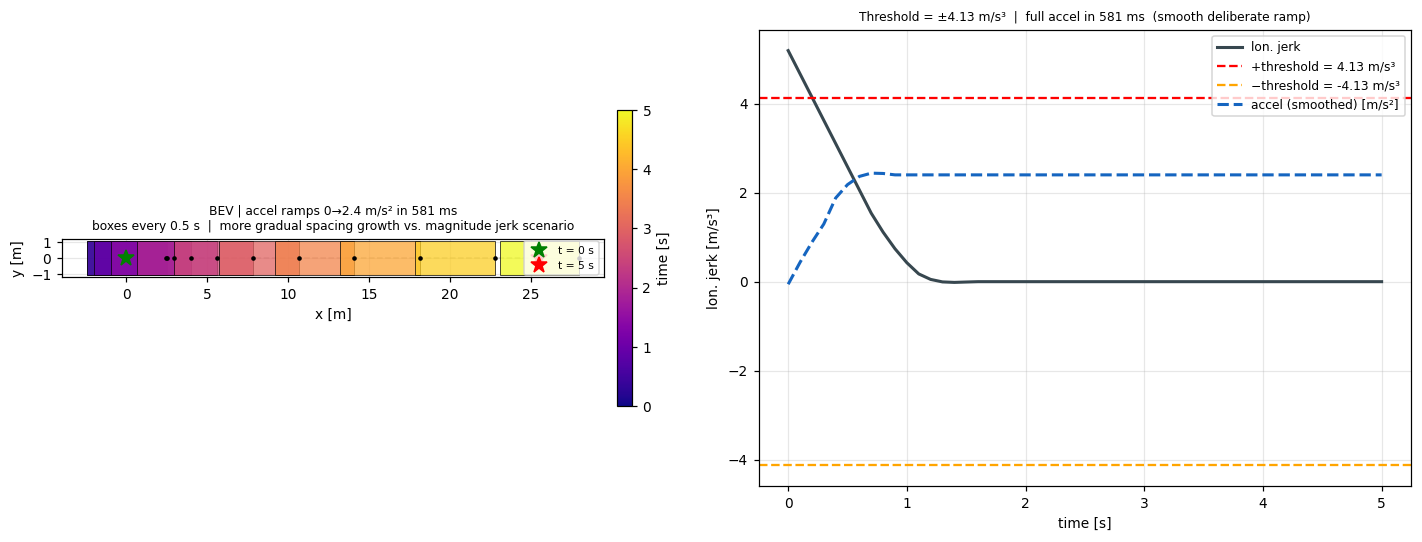

In [7]:
t_ramp4  = MAX_LON_ACCEL / MAX_LON_JERK
accel4   = np.clip(np.where(time <= t_ramp4,
                             (MAX_LON_ACCEL / t_ramp4) * time,
                             MAX_LON_ACCEL), 0, MAX_LON_ACCEL)
accel4_s = sg_smooth(accel4)
lon_jerk4 = sg_diff(accel4_s, deriv=1, window=15)
speed4    = euler_integrate(accel4, init=0.0)
heading4  = np.zeros(N)
x, y      = xy_from_speed_heading(speed4, heading4)

plot_metric(
    x, y, heading4, lon_jerk4,
    threshold=MAX_LON_JERK,
    metric_name="lon. jerk", unit="m/s\u00b3",
    bev_title=(
        f"BEV | accel ramps 0\u2192{MAX_LON_ACCEL} m/s\u00b2 in {t_ramp4*1000:.0f} ms\n"
        "boxes every 0.5 s  |  more gradual spacing growth vs. magnitude jerk scenario"
    ),
    metric_title=(
        f"Threshold = \u00b1{MAX_LON_JERK} m/s\u00b3  |  "
        f"full accel in {t_ramp4*1000:.0f} ms  (smooth deliberate ramp)"
    ),
    color_metric="#37474F",
    mirror=True,
    extra_lines=[(accel4_s, "#1565C0", "--", "accel (smoothed) [m/s\u00b2]")],
)

---
## 6. Yaw Rate (±0.95 rad/s) & Yaw Acceleration (±1.93 rad/s²)

These two are shown together — the yaw rate ramp-up creates the yaw acceleration transient.

**Scenario:** vehicle at 36 km/h. Yaw rate ramps 0 → 0.95 rad/s in `t_ramp ≈ 490 ms`, then holds.  
Steady-state turn radius: `r = v / ω = 10 / 0.95 ≈ 10.5 m`.

**BEV read:** early boxes point roughly right (low yaw rate during ramp), then progressively rotate as the vehicle enters the tight circular arc. The vehicle nearly completes **two full circles** in 5 s.

> **Yaw rate (±0.95 rad/s = ±54°/s):** tight U-turn in a wide street. At 20 km/h the same yaw rate gives r ≈ 5.8 m — three-point-turn territory.  
> **Yaw accel (±1.93 rad/s²):** how fast the steering is cranked. Flicking to full yaw rate in ~500 ms is the limit — faster than this would exceed it.

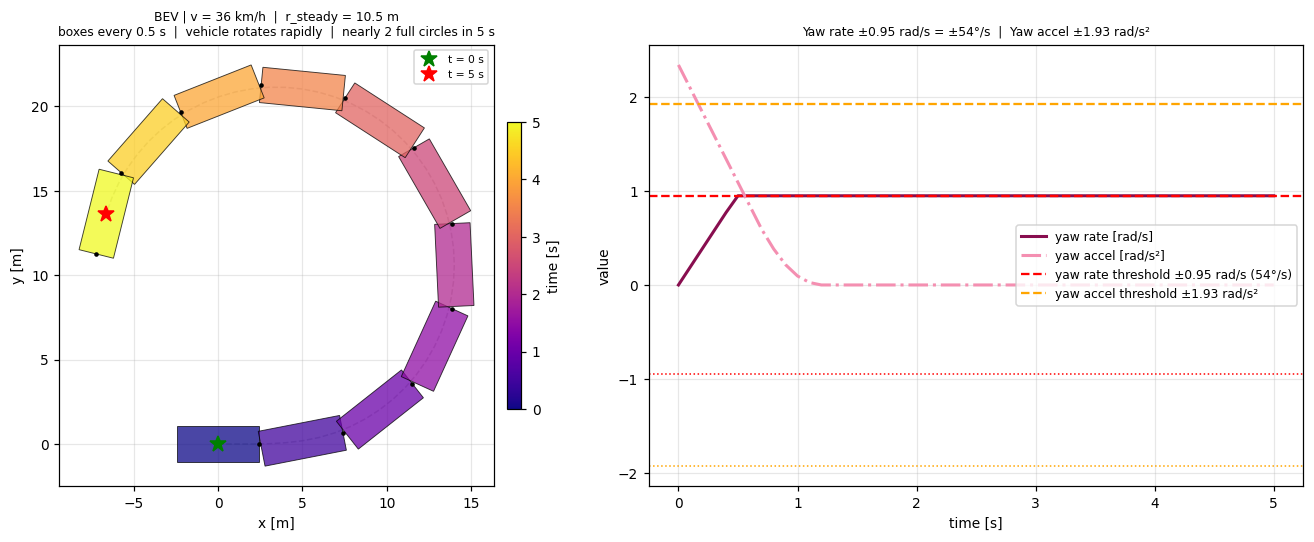

In [8]:
v_yaw    = 10.0
t_ramp5  = MAX_YAW_RATE / MAX_YAW_ACCEL
yaw_rate = np.where(time <= t_ramp5,
                    (MAX_YAW_RATE / t_ramp5) * time,
                    MAX_YAW_RATE)
heading5 = euler_integrate(yaw_rate, init=0.0)
x, y     = xy_from_speed_heading(np.full(N, v_yaw), heading5)
yaw_accel5 = sg_diff(phase_unwrap(heading5), deriv=2, window=15, poly=3)
r_steady = v_yaw / MAX_YAW_RATE

fig, (ax_bev, ax_ts) = plt.subplots(1, 2, figsize=(13, 5))

draw_bev(ax_bev, x, y, heading5)
ax_bev.set_title(
    f"BEV | v = {v_yaw*3.6:.0f} km/h  |  r_steady = {r_steady:.1f} m\n"
    f"boxes every 0.5 s  |  vehicle rotates rapidly  |  nearly 2 full circles in {T:.0f} s",
    fontsize=8
)

ax_ts.plot(time, yaw_rate,   color="#880E4F", lw=2,      label="yaw rate [rad/s]")
ax_ts.plot(time, yaw_accel5, color="#F48FB1", lw=2, ls="-.", label="yaw accel [rad/s\u00b2]")
ax_ts.axhline( MAX_YAW_RATE,  color="red",    lw=1.5, ls="--",
              label=f"yaw rate threshold \u00b1{MAX_YAW_RATE} rad/s ({np.degrees(MAX_YAW_RATE):.0f}\u00b0/s)")
ax_ts.axhline(-MAX_YAW_RATE,  color="red",    lw=1.0, ls=":")
ax_ts.axhline( MAX_YAW_ACCEL, color="orange", lw=1.5, ls="--",
              label=f"yaw accel threshold \u00b1{MAX_YAW_ACCEL} rad/s\u00b2")
ax_ts.axhline(-MAX_YAW_ACCEL, color="orange", lw=1.0, ls=":")
ax_ts.set_xlabel("time [s]")
ax_ts.set_ylabel("value")
ax_ts.set_title(
    f"Yaw rate \u00b1{MAX_YAW_RATE} rad/s = \u00b1{np.degrees(MAX_YAW_RATE):.0f}\u00b0/s  |  "
    f"Yaw accel \u00b1{MAX_YAW_ACCEL} rad/s\u00b2",
    fontsize=8
)
ax_ts.legend(fontsize=8, loc="center right")
ax_ts.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary — Real-world Equivalents at Each Threshold

| Metric | Threshold | Real-world equivalent |
|---|---|---|
| Lon. accel (fwd) | +2.40 m/s² | 0 → 43 km/h in 5 s — moderate city pull-away |
| Lon. accel (brk) | −4.05 m/s² | 60 → 0 km/h in 4.1 s — firm controlled emergency stop |
| Lat. accel | ±4.89 m/s² | 30 km/h on a 14 m radius — tight city corner |
| Magnitude jerk | ±8.37 m/s³ | Full acceleration reached in ~290 ms — brisk floor-it |
| Longitudinal jerk | ±4.13 m/s³ | Full acceleration reached in ~580 ms — deliberate smooth ramp |
| Yaw rate | ±0.95 rad/s | 54°/s — at 36 km/h gives r = 10.5 m (tight U-turn) |
| Yaw accel | ±1.93 rad/s² | Max yaw rate reached in ~490 ms — sharp turn entry |

In [9]:
rows = [
    ("lon. accel (fwd)",   f"+{MAX_LON_ACCEL} m/s\u00b2",  "0 \u2192 43 km/h in 5 s \u2014 moderate city pull-away"),
    ("lon. accel (brk)",   f"{MIN_LON_ACCEL} m/s\u00b2",   "60 \u2192 0 km/h in 4.1 s \u2014 firm controlled emergency stop"),
    ("lat. accel",         f"\u00b1{MAX_LAT_ACCEL} m/s\u00b2",  "30 km/h on r=14 m \u2014 tight city corner"),
    ("magnitude jerk",    f"\u00b1{MAX_MAG_JERK} m/s\u00b3",  "full accel in ~290 ms \u2014 brisk floor-it"),
    ("longitudinal jerk", f"\u00b1{MAX_LON_JERK} m/s\u00b3",  "full accel in ~580 ms \u2014 deliberate smooth ramp"),
    ("yaw rate",          f"\u00b1{MAX_YAW_RATE} rad/s",   f"\u00b1{np.degrees(MAX_YAW_RATE):.0f}\u00b0/s  at 36 km/h \u2192 r=10.5 m  (tight U-turn)"),
    ("yaw accel",         f"\u00b1{MAX_YAW_ACCEL} rad/s\u00b2", "max yaw rate in ~490 ms \u2014 sharp turn entry"),
]

print(f"{'Metric':<22} {'Threshold':<18} Real-world equivalent")
print("\u2500" * 82)
for name, thresh, meaning in rows:
    print(f"{name:<22} {thresh:<18} {meaning}")

Metric                 Threshold          Real-world equivalent
──────────────────────────────────────────────────────────────────────────────────
lon. accel (fwd)       +2.4 m/s²          0 → 43 km/h in 5 s — moderate city pull-away
lon. accel (brk)       -4.05 m/s²         60 → 0 km/h in 4.1 s — firm controlled emergency stop
lat. accel             ±4.89 m/s²         30 km/h on r=14 m — tight city corner
magnitude jerk         ±8.37 m/s³         full accel in ~290 ms — brisk floor-it
longitudinal jerk      ±4.13 m/s³         full accel in ~580 ms — deliberate smooth ramp
yaw rate               ±0.95 rad/s        ±54°/s  at 36 km/h → r=10.5 m  (tight U-turn)
yaw accel              ±1.93 rad/s²       max yaw rate in ~490 ms — sharp turn entry
